In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:13pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:80px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:2px;}
table.dataframe{font-size:5xpt;} 
</style>
"""))

In [16]:
import numpy as np
import pandas as pd
import seaborn as sns # iris(데이터프레임)가져오기
from sklearn import datasets # iris(X와 y가 분리되서 numpy) 가져오기
from sklearn.preprocessing import LabelEncoder # 라벨 인코더
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Input, Dense, LeakyReLU, Dropout

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from matplotlib import pyplot as plt

```
- 데이터셋 생성 및 전처리
    X, y(라벨인코딩)분리 → train_test_split 분리(8:2)
- 모델 구성(입력4, 출력3, layer : 4 → 64 → 128 → 50 → 30 → 3)
    
- 학습과정 설정 (loss='sparse_categorical_crossentropy')
- 학습
- 모델평가(가장 최선의 모델을 get)
- 모델 사용(저장 / 예측)

```
# 1. 기본적인 DNN
## 1. 데이터 셋 생성 및 전처리

In [17]:
# iris 가져오기 방법 1
iris = sns.load_dataset('iris')
iris['species'].value_counts()

setosa        50
versicolor    50
virginica     50
Name: species, dtype: int64

In [19]:
iris_X = iris.iloc[:, :-1].values
labelEncoder = LabelEncoder()
iris_y = labelEncoder.fit_transform(iris.iloc[:, -1]) # 0:setosa/1:versicolor/2:virginica
iris_X.shape, iris_y.shapeape

((150, 4), (150,))

In [22]:
# iris 가져오기 방법 2
iris = datasets.load_iris()
iris_X = iris.data
iris_y = iris.target 
print(iris. target_names)
iris_X.shape, iris_y.shape

['setosa' 'versicolor' 'virginica']


((150, 4), (150,))

In [26]:
# 학습셋과 테스트 셋 분리
train_X, test_X, train_y, test_y = train_test_split(iris_X, iris_y,
                                                    test_size=0.2,
                                                    stratify=iris_y # 층화추출
                                                    )
np.c_[pd.Series(iris_y).value_counts(normalize=True),
      pd.Series(train_y).value_counts(normalize=True),
      pd.Series(test_y).value_counts(normalize=True)]


array([[0.33333333, 0.33333333, 0.33333333],
       [0.33333333, 0.33333333, 0.33333333],
       [0.33333333, 0.33333333, 0.33333333]])

In [27]:
train_X.shape,train_y.shape, test_X.shape, test_y.shape

((120, 4), (120,), (30, 4), (30,))

## 2. 모델 구성 및 학습
- 4 → 64 → 128 → 50 → 30 →3
- He초기화, 다양한 activation, 배치정규화, L2정규화, Dropout

In [42]:
model = Sequential([
    Input(4),
    Dense(units=64, activation='relu'),
    Dense(units=128, activation='relu'),
    Dense(units=50, activation='relu'),
    Dense(units=30, activation='relu'),
    Dense(units=3, activation='softmax'),
],'sequential')

# model = Sequential(name='sequential')
# model.add(Input(4))
# model.add(Dense(units=64, activation='relu'))
# model.add(Dense(units=128, activation='relu'))
# model.add(Dense(units=50, activation='relu'))
# model.add(Dense(units=30, activation='relu'))
# model.add(Dense(units=3, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_30 (Dense)            (None, 64)                320       
                                                                 
 dense_31 (Dense)            (None, 128)               8320      
                                                                 
 dense_32 (Dense)            (None, 50)                6450      
                                                                 
 dense_33 (Dense)            (None, 30)                1530      
                                                                 
 dense_34 (Dense)            (None, 3)                 93        
                                                                 
Total params: 16,713
Trainable params: 16,713
Non-trainable params: 0
_________________________________________________________________


In [43]:
%%time
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
             metrics=['accuracy'])
earlystopping = EarlyStopping(patience=40) # monitor='val_loss'가 기본값
model_save_folder = 'model/'
import os
if not os.path.exists(model_save_folder):
    os.mkdir(model_save_folder)
file = model_save_folder + 'iris-{epoch:03d}-loss{val_loss:.4f}-acc{val_accuracy:.4f}.h5'
checkpoint = ModelCheckpoint(monitor='val_loss',
                             filepath=file, # 모델 저장 파일
                             save_best_only=True, # 모니터 지표가 개선된 경우만 모델 저장
                             # mode='max',
                             verbose=1 # 저장 여부 로그 출력
                            )
hist = model.fit(train_X, train_y,
                epochs=200,
                validation_split=0.1,
                callbacks=[earlystopping, checkpoint],
                verbose=1)

Epoch 1/200
1/4 [======>.......................] - ETA: 0s - loss: 1.1333 - accuracy: 0.2500
Epoch 1: val_loss improved from inf to 0.94289, saving model to model\iris-001-loss0.9429-acc0.7500.h5
4/4 [==============================] - 0s 52ms/step - loss: 1.0569 - accuracy: 0.5000 - val_loss: 0.9429 - val_accuracy: 0.7500
Epoch 2/200
1/4 [======>.......................] - ETA: 0s - loss: 0.9369 - accuracy: 0.7812
Epoch 2: val_loss improved from 0.94289 to 0.84627, saving model to model\iris-002-loss0.8463-acc0.7500.h5
4/4 [==============================] - 0s 25ms/step - loss: 0.9441 - accuracy: 0.6574 - val_loss: 0.8463 - val_accuracy: 0.7500
Epoch 3/200
1/4 [======>.......................] - ETA: 0s - loss: 0.8887 - accuracy: 0.5938
Epoch 3: val_loss improved from 0.84627 to 0.80750, saving model to model\iris-003-loss0.8075-acc0.8333.h5
4/4 [==============================] - 0s 25ms/step - loss: 0.8538 - accuracy: 0.8426 - val_loss: 0.8075 - val_accuracy: 0.8333
Epoch 4/200
1/4 [===

1/4 [======>.......................] - ETA: 0s - loss: 0.0640 - accuracy: 1.0000
Epoch 26: val_loss improved from 0.10869 to 0.10749, saving model to model\iris-026-loss0.1075-acc0.9167.h5
4/4 [==============================] - 0s 23ms/step - loss: 0.0619 - accuracy: 0.9907 - val_loss: 0.1075 - val_accuracy: 0.9167
Epoch 27/200
1/4 [======>.......................] - ETA: 0s - loss: 0.0834 - accuracy: 0.9688
Epoch 27: val_loss improved from 0.10749 to 0.09920, saving model to model\iris-027-loss0.0992-acc1.0000.h5
4/4 [==============================] - 0s 24ms/step - loss: 0.0674 - accuracy: 0.9815 - val_loss: 0.0992 - val_accuracy: 1.0000
Epoch 28/200
1/4 [======>.......................] - ETA: 0s - loss: 0.0712 - accuracy: 0.9688
Epoch 28: val_loss improved from 0.09920 to 0.09855, saving model to model\iris-028-loss0.0986-acc0.9167.h5
4/4 [==============================] - 0s 23ms/step - loss: 0.1066 - accuracy: 0.9444 - val_loss: 0.0986 - val_accuracy: 0.9167
Epoch 29/200
1/4 [=====

1/4 [======>.......................] - ETA: 0s - loss: 0.0118 - accuracy: 1.0000
Epoch 54: val_loss improved from 0.07396 to 0.07217, saving model to model\iris-054-loss0.0722-acc1.0000.h5
4/4 [==============================] - 0s 24ms/step - loss: 0.0398 - accuracy: 0.9815 - val_loss: 0.0722 - val_accuracy: 1.0000
Epoch 55/200
1/4 [======>.......................] - ETA: 0s - loss: 0.0423 - accuracy: 1.0000
Epoch 55: val_loss improved from 0.07217 to 0.07166, saving model to model\iris-055-loss0.0717-acc1.0000.h5
4/4 [==============================] - 0s 22ms/step - loss: 0.0398 - accuracy: 0.9907 - val_loss: 0.0717 - val_accuracy: 1.0000
Epoch 56/200
1/4 [======>.......................] - ETA: 0s - loss: 0.0631 - accuracy: 0.9688
Epoch 56: val_loss did not improve from 0.07166
4/4 [==============================] - 0s 13ms/step - loss: 0.0428 - accuracy: 0.9907 - val_loss: 0.0808 - val_accuracy: 0.9167
Epoch 57/200
1/4 [======>.......................] - ETA: 0s - loss: 0.0130 - accura

1/4 [======>.......................] - ETA: 0s - loss: 0.0462 - accuracy: 0.9688
Epoch 83: val_loss improved from 0.06279 to 0.06273, saving model to model\iris-083-loss0.0627-acc1.0000.h5
4/4 [==============================] - 0s 24ms/step - loss: 0.0382 - accuracy: 0.9815 - val_loss: 0.0627 - val_accuracy: 1.0000
Epoch 84/200
1/4 [======>.......................] - ETA: 0s - loss: 0.0392 - accuracy: 1.0000
Epoch 84: val_loss did not improve from 0.06273
4/4 [==============================] - 0s 15ms/step - loss: 0.0352 - accuracy: 0.9907 - val_loss: 0.0672 - val_accuracy: 1.0000
Epoch 85/200
1/4 [======>.......................] - ETA: 0s - loss: 0.0179 - accuracy: 1.0000
Epoch 85: val_loss did not improve from 0.06273
4/4 [==============================] - 0s 16ms/step - loss: 0.0394 - accuracy: 0.9815 - val_loss: 0.0653 - val_accuracy: 1.0000
Epoch 86/200
1/4 [======>.......................] - ETA: 0s - loss: 0.0516 - accuracy: 0.9688
Epoch 86: val_loss improved from 0.06273 to 0.060

1/4 [======>.......................] - ETA: 0s - loss: 0.0211 - accuracy: 1.0000
Epoch 111: val_loss did not improve from 0.05408
4/4 [==============================] - 0s 16ms/step - loss: 0.0556 - accuracy: 0.9815 - val_loss: 0.0961 - val_accuracy: 0.9167
Epoch 112/200
1/4 [======>.......................] - ETA: 0s - loss: 0.0071 - accuracy: 1.0000
Epoch 112: val_loss did not improve from 0.05408
4/4 [==============================] - 0s 20ms/step - loss: 0.0350 - accuracy: 0.9815 - val_loss: 0.0706 - val_accuracy: 1.0000
Epoch 113/200
1/4 [======>.......................] - ETA: 0s - loss: 0.0273 - accuracy: 0.9688
Epoch 113: val_loss improved from 0.05408 to 0.05327, saving model to model\iris-113-loss0.0533-acc1.0000.h5
4/4 [==============================] - 0s 31ms/step - loss: 0.0436 - accuracy: 0.9722 - val_loss: 0.0533 - val_accuracy: 1.0000
Epoch 114/200
1/4 [======>.......................] - ETA: 0s - loss: 0.0607 - accuracy: 0.9688
Epoch 114: val_loss did not improve from 0.

4/4 [==============================] - 0s 15ms/step - loss: 0.0430 - accuracy: 0.9815 - val_loss: 0.0443 - val_accuracy: 1.0000
Epoch 140/200
1/4 [======>.......................] - ETA: 0s - loss: 0.0422 - accuracy: 0.9688
Epoch 140: val_loss did not improve from 0.04366
4/4 [==============================] - 0s 15ms/step - loss: 0.0296 - accuracy: 0.9815 - val_loss: 0.0577 - val_accuracy: 1.0000
Epoch 141/200
1/4 [======>.......................] - ETA: 0s - loss: 0.0193 - accuracy: 1.0000
Epoch 141: val_loss did not improve from 0.04366
4/4 [==============================] - 0s 14ms/step - loss: 0.0568 - accuracy: 0.9630 - val_loss: 0.0587 - val_accuracy: 1.0000
Epoch 142/200
1/4 [======>.......................] - ETA: 0s - loss: 0.0584 - accuracy: 0.9688
Epoch 142: val_loss did not improve from 0.04366
4/4 [==============================] - 0s 15ms/step - loss: 0.0758 - accuracy: 0.9722 - val_loss: 0.3440 - val_accuracy: 0.9167
Epoch 143/200
1/4 [======>.......................] - ETA

Epoch 169/200
1/4 [======>.......................] - ETA: 0s - loss: 0.0986 - accuracy: 0.9688
Epoch 169: val_loss did not improve from 0.04010
4/4 [==============================] - 0s 19ms/step - loss: 0.0547 - accuracy: 0.9815 - val_loss: 0.0438 - val_accuracy: 1.0000
Epoch 170/200
1/4 [======>.......................] - ETA: 0s - loss: 0.0498 - accuracy: 0.9688
Epoch 170: val_loss did not improve from 0.04010
4/4 [==============================] - 0s 18ms/step - loss: 0.0358 - accuracy: 0.9815 - val_loss: 0.0958 - val_accuracy: 0.9167
Epoch 171/200
1/4 [======>.......................] - ETA: 0s - loss: 0.0448 - accuracy: 0.9688
Epoch 171: val_loss did not improve from 0.04010
4/4 [==============================] - 0s 18ms/step - loss: 0.0436 - accuracy: 0.9722 - val_loss: 0.0406 - val_accuracy: 1.0000
Epoch 172/200
1/4 [======>.......................] - ETA: 0s - loss: 0.0507 - accuracy: 0.9688
Epoch 172: val_loss did not improve from 0.04010
4/4 [==============================] - 0

1/4 [======>.......................] - ETA: 0s - loss: 0.0016 - accuracy: 1.0000
Epoch 198: val_loss did not improve from 0.03593
4/4 [==============================] - 0s 16ms/step - loss: 0.0379 - accuracy: 0.9815 - val_loss: 0.0606 - val_accuracy: 1.0000
Epoch 199/200
1/4 [======>.......................] - ETA: 0s - loss: 0.0757 - accuracy: 0.9688
Epoch 199: val_loss did not improve from 0.03593
4/4 [==============================] - 0s 15ms/step - loss: 0.0409 - accuracy: 0.9815 - val_loss: 0.0407 - val_accuracy: 1.0000
Epoch 200/200
1/4 [======>.......................] - ETA: 0s - loss: 0.0508 - accuracy: 0.9688
Epoch 200: val_loss did not improve from 0.03593
4/4 [==============================] - 0s 15ms/step - loss: 0.0299 - accuracy: 0.9907 - val_loss: 0.0490 - val_accuracy: 1.0000
CPU times: total: 16.8 s
Wall time: 14 s


##  3. 모델평가

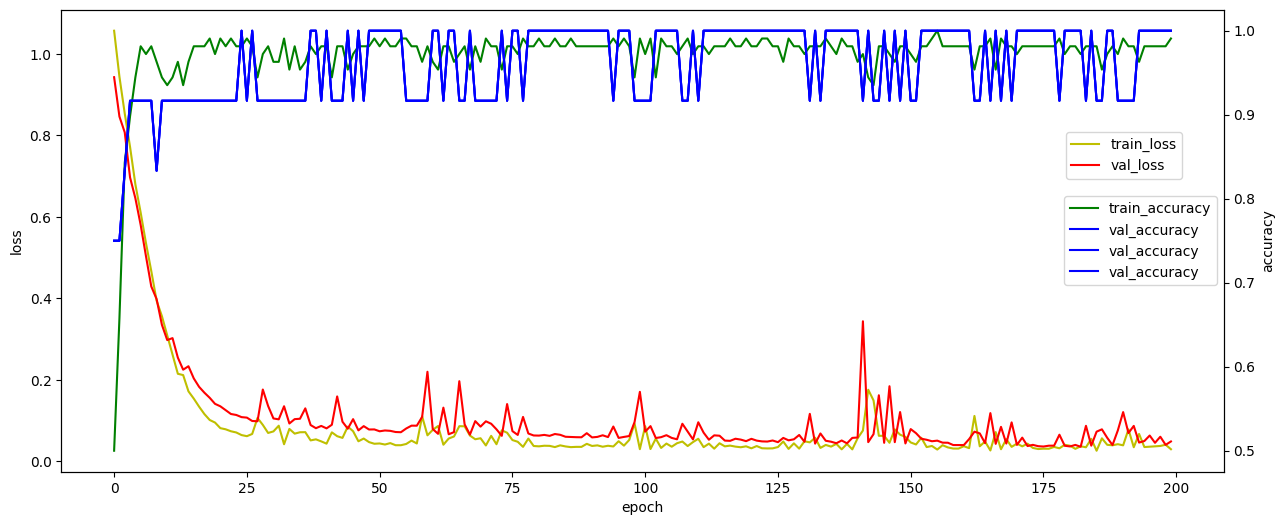

In [44]:
# 학습과정 살펴보기(시각화)
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(bbox_to_anchor=(0.97,0.75))
acc_ax.legend(loc='center right')
plt.show()

In [45]:
# 모델 평가
loss, acc = model.evaluate(test_X, test_y)
print(loss, acc)

1/1 [==============================] - 0s 31ms/step - loss: 0.2001 - accuracy: 0.9667
0.2001388967037201 0.9666666388511658


In [46]:
# 저장된 모델 중 최선 모델
model1 = load_model('model/iris-168-loss0.0227-acc1.0000.h5')
loss1, acc1 = model1.evaluate(test_X, test_y)
print(loss1, acc1)

1/1 [==============================] - 0s 125ms/step - loss: 0.2410 - accuracy: 0.9667
0.24101610481739044 0.9666666388511658


# 2. sklearn 이용
- 4 → 64 → 128 → 50 → 30 →3

In [47]:
from sklearn.neural_network import MLPClassifier # multi-layer perceptron
# 1. 데이터
train_X.shape, train_y.shape, test_X.shape, test_y.shape

((120, 4), (120,), (30, 4), (30,))

In [48]:
# 2. 모델 생성
model = MLPClassifier(hidden_layer_sizes=(64, 128, 50, 30),
                      activation='relu',
                      solver='adam',
                      batch_size=40,
                      early_stopping=True,
                      n_iter_no_change=50,
                      validation_fraction=0.1,
                      max_iter=200,
                      warm_start=False,
                      )

In [49]:
# 3. 모델 학습
model.fit(train_X, train_y)

MLPClassifier(batch_size=40, early_stopping=True,
              hidden_layer_sizes=(64, 128, 50, 30), n_iter_no_change=50)

In [50]:
# 4. 모델 평가
model.score(test_X, test_y)

0.8666666666666667

In [52]:
# 5. 교차표(혼동행렬)
# 실제값 : test_y
y_hat = model.predict(test_X)
pd.crosstab(test_y, y_hat, rownames=['real'], colnames=['prediect'])

prediect,0,1,2
real,,,
0,10,0,0
1,0,6,4
2,0,0,10


In [54]:
from sklearn.metrics import confusion_matrix
confusion_matrix(test_y, y_hat)

array([[10,  0,  0],
       [ 0,  6,  4],
       [ 0,  0, 10]], dtype=int64)

# 3. 클래스를 생성하여 모델 생성함수 사용

In [56]:
class DNNClassifier:
    @staticmethod
    def build(input_dim=4, activation='relu', output_dim=3, optimizer='adam'):
        # 모델 구성
        model = Sequential(layers=[
            Input(input_dim),
            Dense(units=50, activation=activation),
            Dense(units=30, activation=activation),
            Dense(units=output_dim, activation='softmax')
        ], name='sequential')
        # 모델 학습 설정
        model.compile(loss='sparse_categorical_crossentropy',
                     optimizer=optimizer,
                     metrics=['accuracy'])
        # 모델 return
        return model

In [58]:
%%time
# 데이터 
print(train_X.shape, train_y.shape, test_X.shape, test_y.shape)

#2. 모델
model = DNNClassifier.build(input_dim=4, activation='relu', output_dim=3, optimizer='adam')

# 3. 모델 학습
hist = model.fit(train_X, train_y,
                epochs=50,
                validation_split=0.1,
                verbose=1)

(120, 4) (120,) (30, 4) (30,)
Epoch 1/50
4/4 [==============================] - 0s 41ms/step - loss: 1.4362 - accuracy: 0.3241 - val_loss: 1.1633 - val_accuracy: 0.4167
Epoch 2/50
4/4 [==============================] - 0s 15ms/step - loss: 1.2702 - accuracy: 0.3241 - val_loss: 1.0899 - val_accuracy: 0.4167
Epoch 3/50
4/4 [==============================] - 0s 15ms/step - loss: 1.1660 - accuracy: 0.3704 - val_loss: 1.0313 - val_accuracy: 0.7500
Epoch 4/50
4/4 [==============================] - 0s 14ms/step - loss: 1.0908 - accuracy: 0.6481 - val_loss: 0.9850 - val_accuracy: 0.7500
Epoch 5/50
4/4 [==============================] - 0s 14ms/step - loss: 1.0338 - accuracy: 0.6574 - val_loss: 0.9464 - val_accuracy: 0.7500
Epoch 6/50
4/4 [==============================] - 0s 16ms/step - loss: 0.9844 - accuracy: 0.6574 - val_loss: 0.9121 - val_accuracy: 0.7500
Epoch 7/50
4/4 [==============================] - 0s 14ms/step - loss: 0.9411 - accuracy: 0.6481 - val_loss: 0.8851 - val_accuracy: 0.75

In [59]:
# 모델 평가
loss, accuracy = model.evaluate(test_X, test_y, verbose=0)
print(f'정확도 :{accuracy*100}%')

정확도 :93.33333373069763%


# 4. 함수형 API 이용
- 병렬처리, Residual block

## ▶ 기존 model 스타일 1

In [ ]:
model = Sequential(layers=[
    Input(shape=(4,)),
    Dense(units=50, activation='relu'),
    Dense(units=30, activation='relu'),
    Dense(units=3, activation='softmax'),
])

## ▶ 기존 model 스타일 2

In [62]:
model = Sequential()
model.add(Input(shape=(4,)))
model.add(Dense(units=50, activation='relu'))
model.add(Dense(units=30, activation='relu'))
model.add(Dense(units=3, activation='softmax'))
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_47 (Dense)            (None, 50)                250       
                                                                 
 dense_48 (Dense)            (None, 30)                1530      
                                                                 
 dense_49 (Dense)            (None, 3)                 93        
                                                                 
Total params: 1,873
Trainable params: 1,873
Non-trainable params: 0
_________________________________________________________________


## ▶ 함수형 API 스타일

In [60]:
from tensorflow.keras import Model
input_ = Input(shape=(4,))
layer1 = Dense(units=50, activation='relu')(input_)
layer2 = Dense(units=30, activation='relu')(layer1)
output = Dense(units=3, activation='softmax')(layer2)
model = Model(inputs=input_, outputs=output)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_10 (InputLayer)       [(None, 4)]               0         
                                                                 
 dense_41 (Dense)            (None, 50)                250       
                                                                 
 dense_42 (Dense)            (None, 30)                1530      
                                                                 
 dense_43 (Dense)            (None, 3)                 93        
                                                                 
Total params: 1,873
Trainable params: 1,873
Non-trainable params: 0
_________________________________________________________________


In [67]:
# 4 → 160 →3 
# 기존의 model 방식
model = Sequential([
    Input(shape=(4,)),
    Dense(units=160, activation='relu'),
    Dense(units=3, activation='softmax')
])

# 함수형 API 방식
input_ = Input(shape=(4,))
layer = Dense(units=160, activation='relu')(input_)
output = Dense(units=3, activation='softmax')(layer)
model = Model(inputs=input_, outputs=output)
model.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_20 (InputLayer)       [(None, 4)]               0         
                                                                 
 dense_67 (Dense)            (None, 160)               800       
                                                                 
 dense_68 (Dense)            (None, 3)                 483       
                                                                 
Total params: 1,283
Trainable params: 1,283
Non-trainable params: 0
_________________________________________________________________


In [65]:
# 4 → 160 →3 병렬처리 방식
from tensorflow.keras.layers import concatenate
input_ = Input(shape=(4,))
dense1 = Dense(units=50, activation='relu')(input_)
dense2 = Dense(units=80, activation='relu')(input_)
dense3 = Dense(units=30, activation='relu')(input_)
x      = concatenate([dense1, dense2, dense3])
output = Dense(units=3, activation='softmax')(x)
model = Model(input_, outputs=output)
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_16 (InputLayer)          [(None, 4)]          0           []                               
                                                                                                  
 dense_57 (Dense)               (None, 50)           250         ['input_16[0][0]']               
                                                                                                  
 dense_58 (Dense)               (None, 80)           400         ['input_16[0][0]']               
                                                                                                  
 dense_59 (Dense)               (None, 30)           150         ['input_16[0][0]']               
                                                                                            

In [68]:
# 레디듀에 블럭(Resiaual Black)
from tensorflow.keras.layers import add
input_ = Input(shape=(4,))
dense1 = Dense(units=50, activation='relu')(input_)
layer1 = Dense(units=64, activation='relu')(dense1)
layer2 = Dense(units=50, activation='relu')(layer1)
dense2 = add([dense1, layer2])
output = Dense(units=3, activation='softmax')(dense2)
model = Model(inputs=input_, outputs=output)
model.summary()

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_21 (InputLayer)          [(None, 4)]          0           []                               
                                                                                                  
 dense_69 (Dense)               (None, 50)           250         ['input_21[0][0]']               
                                                                                                  
 dense_70 (Dense)               (None, 64)           3264        ['dense_69[0][0]']               
                                                                                                  
 dense_71 (Dense)               (None, 50)           3250        ['dense_70[0][0]']               
                                                                                            